# Demo: ReLU vs Leaky ReLU vs Dropout
This notebook is designed for the conceptual part of the lecture:
- simple nonlinear dataset (`make_moons`)
- compare small neural networks using ReLU, Leaky ReLU, and Dropout
- illustrate the dying ReLU issue (high LR)
- visualize decision boundaries and training curves

**Note:** This notebook uses **PyTorch** because scikit-learn's MLP focuses on standard feedforward networks and does not expose dropout or Leaky ReLU layers directly in the same way as deep-learning libraries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

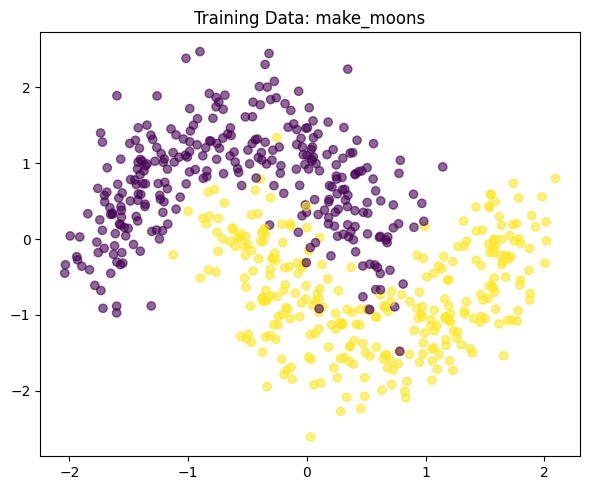

In [2]:
# Generate data
X, y = make_moons(n_samples=800, noise=0.22, random_state=RANDOM_STATE)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32)

plt.figure(figsize=(6, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, alpha=0.6)
plt.title("Training Data: make_moons")
plt.tight_layout()
plt.show()

In [3]:
class SimpleNet(nn.Module):
    def __init__(self, activation="relu", dropout_rate=0.0):
        super().__init__()

        if activation == "relu":
            act = nn.ReLU()
        elif activation == "leaky_relu":
            act = nn.LeakyReLU(negative_slope=0.01)
        else:
            raise ValueError("activation must be 'relu' or 'leaky_relu'")

        self.fc1 = nn.Linear(2, 16)
        self.act1 = act
        self.drop1 = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(16, 16)
        self.act2 = act.__class__() if activation == "relu" else nn.LeakyReLU(negative_slope=0.01)
        self.drop2 = nn.Dropout(dropout_rate)
        self.out = nn.Linear(16, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act1(x)
        x = self.drop1(x)
        x = self.fc2(x)
        x = self.act2(x)
        x = self.drop2(x)
        x = self.out(x)
        return x

In [4]:
def count_dead_relu_units(model, X_tensor):
    dead_count = 0
    total_units = 0

    with torch.no_grad():
        z1 = model.fc1(X_tensor)
        a1 = model.act1(z1)
        z2 = model.fc2(model.drop1(a1))
        a2 = model.act2(z2)

        for activations in [a1, a2]:
            # a unit is considered "dead" here if it outputs zero for every sample in the batch
            dead_count += (activations == 0).all(dim=0).sum().item()
            total_units += activations.shape[1]

    return dead_count, total_units

In [5]:
def train_model(model, X_train_t, y_train_t, X_test_t, y_test_t, lr=0.01, epochs=300):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    test_accs = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(X_train_t)
        loss = criterion(logits, y_train_t)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            test_logits = model(X_test_t)
            test_probs = torch.sigmoid(test_logits).numpy().ravel()
            test_pred = (test_probs >= 0.5).astype(int)
            test_acc = accuracy_score(y_test_t.numpy().ravel(), test_pred)
            test_accs.append(test_acc)

    return train_losses, test_accs

In [6]:
configs = {
    "ReLU": {"activation": "relu", "dropout_rate": 0.0, "lr": 0.01},
    "Leaky ReLU": {"activation": "leaky_relu", "dropout_rate": 0.0, "lr": 0.01},
    "ReLU + Dropout": {"activation": "relu", "dropout_rate": 0.25, "lr": 0.01},
    # this intentionally aggressive setting often increases inactive ReLU behavior
    "ReLU (high LR)": {"activation": "relu", "dropout_rate": 0.0, "lr": 0.20}, # learning rate set very high
}

trained_models = {}
histories = {}

for name, cfg in configs.items():
    model = SimpleNet(activation=cfg["activation"], dropout_rate=cfg["dropout_rate"])
    losses, accs = train_model(
        model, X_train_t, y_train_t, X_test_t, y_test_t, lr=cfg["lr"], epochs=300
    )
    trained_models[name] = model
    histories[name] = {"losses": losses, "accs": accs}

print("Training complete.")

Training complete.


In [7]:
# Compare final test accuracy and dead ReLU counts
rows = []
for name, model in trained_models.items():
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(X_test_t)).numpy().ravel()
        pred = (probs >= 0.5).astype(int)
        acc = accuracy_score(y_test, pred)

    dead_count, total_units = count_dead_relu_units(model, X_train_t) if "ReLU" in name else (np.nan, np.nan)

    rows.append({
        "Model": name,
        "Test Accuracy": acc,
        "Dead Units (train batch check)": dead_count,
        "Total Hidden Units Checked": total_units
    })

import pandas as pd
pd.DataFrame(rows).sort_values("Test Accuracy", ascending=False)

,Model,Test Accuracy,Dead Units (train batch check),Total Hidden Units Checked
0,ReLU,0.960,7,32
1,Leaky ReLU,0.960,0,32
2,ReLU + Dropout,0.960,2,32
3,ReLU (high LR),0.955,9,32


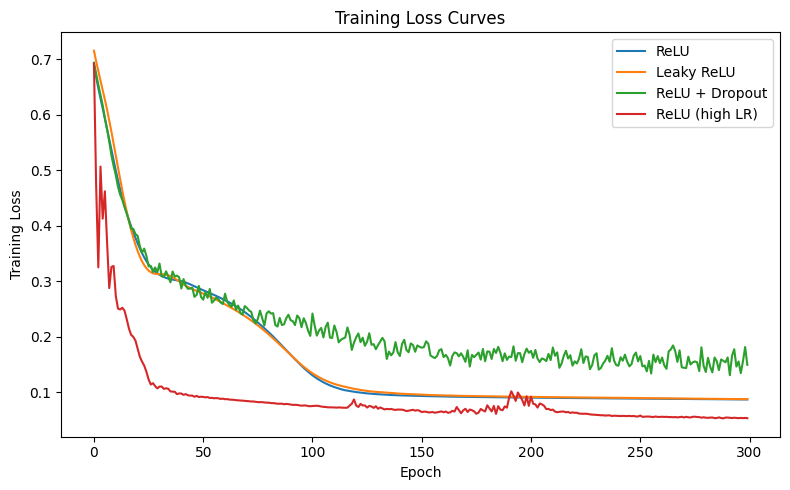

In [8]:
# Plot training loss curves
plt.figure(figsize=(8, 5))
for name, hist in histories.items():
    plt.plot(hist["losses"], label=name)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curves")
plt.legend()
plt.tight_layout()
plt.show()

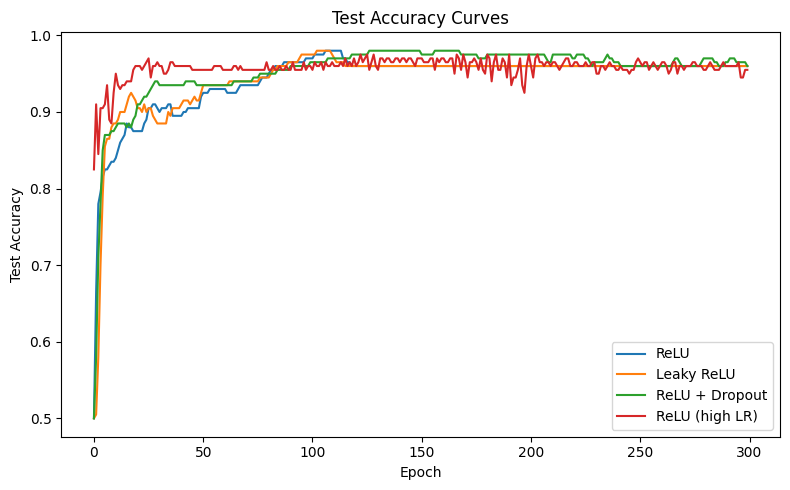

In [9]:
# Plot test accuracy curves
plt.figure(figsize=(8, 5))
for name, hist in histories.items():
    plt.plot(hist["accs"], label=name)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Curves")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_t = torch.tensor(grid, dtype=torch.float32)

    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(grid_t)).numpy().reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, probs >= 0.5, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", alpha=0.7)
    plt.title(title)
    plt.tight_layout()
    plt.show()

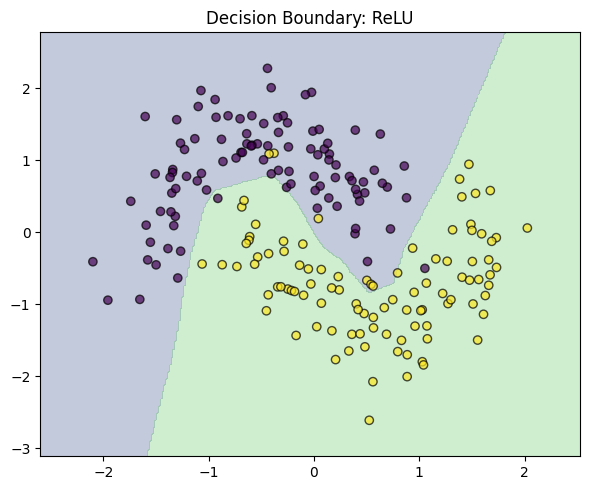

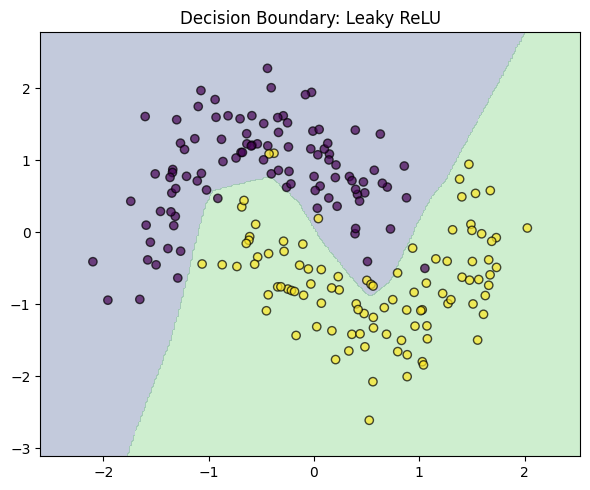

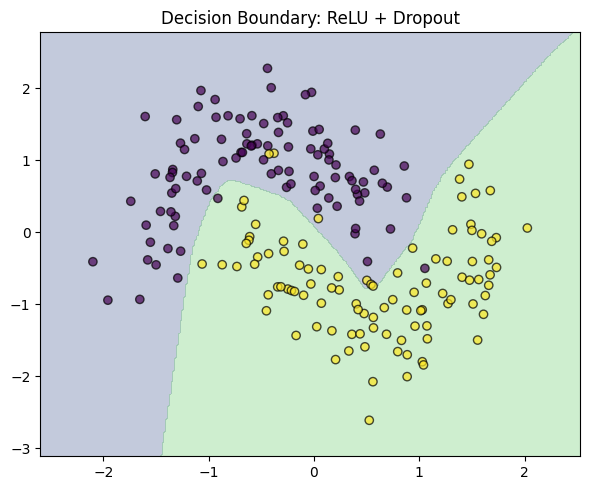

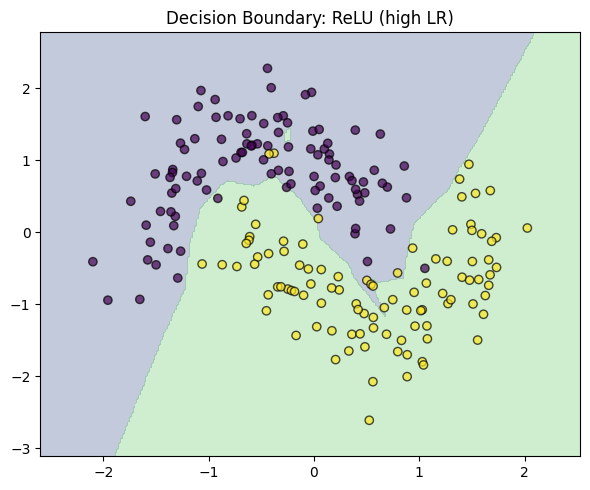

In [11]:
for name, model in trained_models.items():
    plot_decision_boundary(model, X_test, y_test, f"Decision Boundary: {name}")

## Discussion prompts
- Did the very high learning rate increase the chance of inactive ReLU units?
- Does Leaky ReLU help preserve gradient flow?
- Did Dropout mainly improve optimization, or generalization?
- Why is Dropout not exactly the same thing as fixing dying ReLU?